In [1]:
from colorama import Fore
from IPython.display import display, Math

from astropy.io import fits
from scipy.io import readsav
from scipy.stats import gaussian_kde
from scipy import stats as ss
import numpy as np
import pandas as pd
import os
import copy

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import tools as t

In [2]:
# load TS1
path_data = '../data/sim_series/'  # directory where the files are saved
data_spectra = fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie0.fits')
data_spectra = np.array(data_spectra)

times = np.arange(0, len(data_spectra) * 144, 144) / 60 / 24  # time in days, same for all time series

In [3]:
# Parameters

N = 3686  # timesteps
M = 20  # PCs
TS = 1  # time series used

# Load data

X = []
y = []

for i in range(N):

    data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')

    X.append(data['scores'].float())
    y.append(torch.as_tensor(data['rv'], dtype=torch.float32))

X = torch.stack(X)
y = torch.stack(y).reshape(-1, 1)

print("Total X shape:", X.shape)
print("Total y shape:", y.shape)

/tmp/ipykernel_2940972/3950740032.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')


Total X shape: torch.Size([3686, 20])
Total y shape: torch.Size([3686, 1])


In [4]:
# RV stats
print(f'Mean: {y.mean().item()}')
print(f'Sigma: {y.std().item()}')
print(f'Min: {y.min().item()}')
print(f'Max: {y.max().item()}')

Mean: -3.8809319646837537e-10
Sigma: 0.9465776681900024
Min: -3.7014224529266357
Max: 3.3682401180267334


In [5]:
int(.7 * N) % 21

18

In [6]:
.7*N

2580.2

In [7]:
batch_size = 1
chunk_size = 21

# Chronological train/test split

train_size = int(0.7 * N)
# cut beginning and end of the arrays so all chunks have the same size
rest_train = train_size % chunk_size
rest_test  = (N - train_size) % chunk_size

X_train = X[rest_train:train_size]
y_train = y[rest_train:train_size]

X_test = X[train_size:-rest_test]
y_test = y[train_size:-rest_test]

# scale scores (X)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.numpy())
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)

X_test_scaled = scaler.transform(X_test.numpy())
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

# reshape into chunks
X_train = X_train.reshape((-1, chunk_size, M))
y_train = y_train.reshape((-1, chunk_size, 1))

X_test = X_test.reshape((-1, chunk_size, M))
y_test = y_test.reshape((-1, chunk_size, 1))

print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)

print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

Train X shape: torch.Size([122, 21, 20])
Train y shape: torch.Size([122, 21, 1])
Test X shape: torch.Size([52, 21, 20])
Test y shape: torch.Size([52, 21, 1])


In [8]:
# DataSets and DataLoaders

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True
)

test_dataset = TensorDataset(X_test, y_test)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

In [9]:
# model parameters
# M = 20 PCs
model = nn.Sequential(
    nn.Linear(M, 32),
    nn.ReLU(),

    nn.Linear(32, 16),
    nn.ReLU(),

    nn.Linear(16, 1),
)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0
)

In [10]:
# Training
epochs = 200
model_history = {
    'y_train_true': [],
    'y_train_pred': [],
    'diff_train': [],
    'loss_train': [],
}

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        y_pred = model(X_batch)

        # Calculate loss
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Average loss over batches
    train_loss /= len(train_loader)

    # Evaluate train set
    y_tr_true, y_tr_pred, diff_tr, loss_tr = t.evaluate_model(train_loader, model, criterion)

    # Save evaluation
    model_history['y_train_true'].append(y_tr_true)
    model_history['y_train_pred'].append(y_tr_pred)
    model_history['diff_train'].append(diff_tr)
    model_history['loss_train'].append(loss_tr)

    # Print progress
    if epoch % (epochs // 10) == 0 or epoch == epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"train loss = {train_loss:.4f}"
        )

Epoch 0: train loss = 0.9268
Epoch 20: train loss = 0.0597
Epoch 40: train loss = 0.0396
Epoch 60: train loss = 0.0324
Epoch 80: train loss = 0.0291
Epoch 100: train loss = 0.0272
Epoch 120: train loss = 0.0259
Epoch 140: train loss = 0.0248
Epoch 160: train loss = 0.0239
Epoch 180: train loss = 0.0232
Epoch 199: train loss = 0.0225


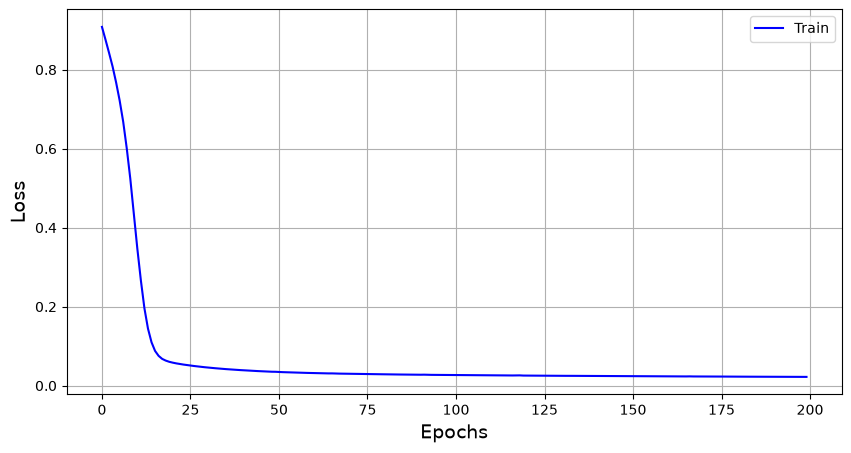

In [11]:
# plot loss history

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()

ax.plot(model_history['loss_train'], color='blue', label='Train')
#ax.plot(model_history['loss_test'], color='red', label='Test')

ax.set_xlabel('Epochs', size=14)
ax.set_ylabel('Loss', size=14)
#ax.set_yscale('log')
ax.legend()

plt.show()

In [12]:
# Evaluating the best model
model.eval()

# Evaluate training set
y_train_true, y_train_pred, diff_train, loss_train = t.evaluate_model(train_loader, model, criterion)

# Evaluate testing set
y_test_true, y_test_pred, diff_test, loss_test = t.evaluate_model(test_loader, model, criterion)

# Print results
print('---------- Best model average loss ----------')
print(f'Train loss: {loss_train:.4f}')
print(f'Test loss: {loss_test:.4f}')

---------- Best model average loss ----------
Train loss: 0.0222
Test loss: 0.0369


In [13]:
X_test.shape

torch.Size([52, 21, 20])

In [16]:
y_test_true.shape

(52, 21)

In [16]:
mean_res_test_nn = np.array([np.mean(i) for i in res_test_nn])
std_res_test_nn = np.array([np.std(i) for i in res_test_nn])

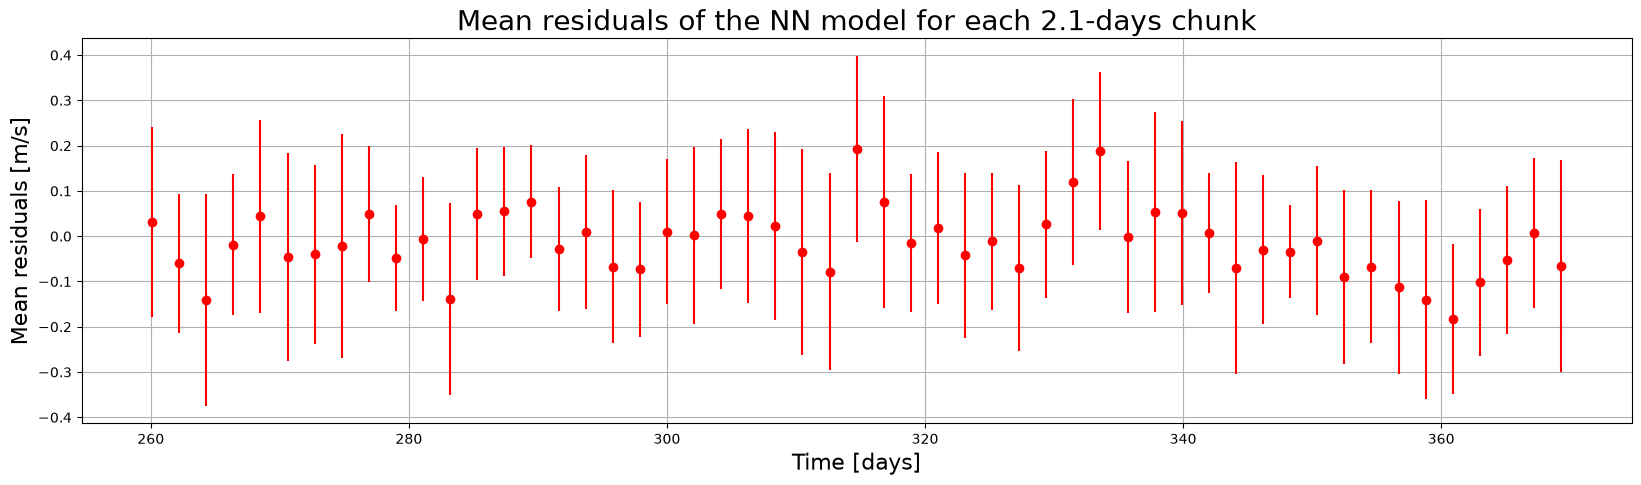

In [17]:
chunk_array = (np.linspace(1, len(y_test_nn), len(y_test_nn)) * chunk_size + train_size) * 144 / 60 / 24  # array of days corresponding to the test sample

fig, ax = plt.subplots(figsize=(20, 5))
ax.grid()
ax.set_title(f'Mean residuals of the NN model for each {chunk_size / 10}-days chunk', size=20)

ax.errorbar(chunk_array, mean_res_test_nn, std_res_test_nn, color='red', fmt='o')
ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('Mean residuals [m/s]', size=16)

plt.show()

In [19]:
y_test_nn_flat = np.concatenate(y_test_nn)
y_test_true_flat = np.concatenate(y_test_true)
diff_test_nn   = y_test_true_flat - y_test_nn_flat

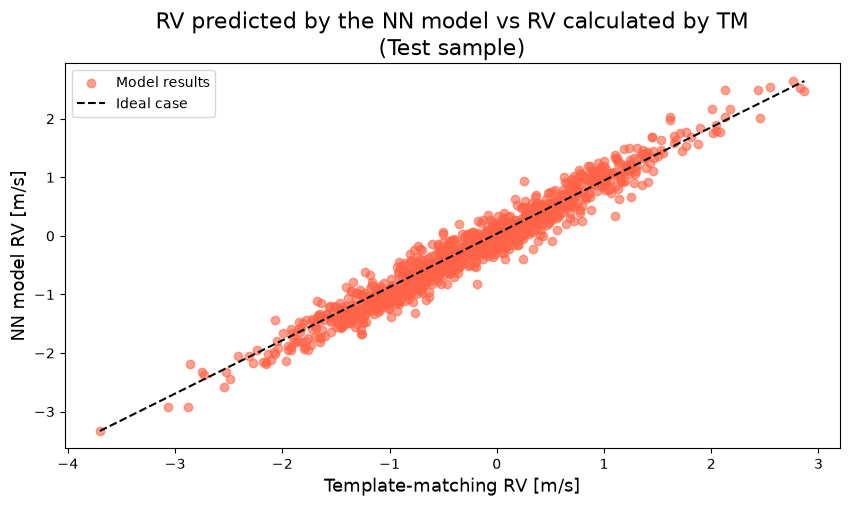

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('RV predicted by the NN model vs RV calculated by TM\n(Test sample)', size=16)

ax.scatter(y_test_true_flat, y_test_nn_flat, color='tomato', alpha=.6, label='Model results')
ax.plot([min(y_test_true_flat), max(y_test_true_flat)], [min(y_test_nn_flat), max(y_test_nn_flat)], linestyle='--', color='k', label='Ideal case')
ax.set_xlabel('Template-matching RV [m/s]', size=13)
ax.set_ylabel('NN model RV [m/s]', size=13)
ax.legend()

plt.show()

In [23]:
# best model loss for each point

criterion_L1    = nn.L1Loss(reduction="none")
criterion_MSE   = nn.MSELoss(reduction="none")
criterion_Huber = nn.HuberLoss(reduction="none")

loss_L1_train = criterion_L1(torch.tensor(y_train_pred), torch.tensor(y_train_true))
loss_MSE_train = criterion_MSE(torch.tensor(y_train_pred), torch.tensor(y_train_true))
loss_Huber_train = criterion_Huber(torch.tensor(y_train_pred), torch.tensor(y_train_true))

loss_L1_test = criterion_L1(torch.tensor(y_test_nn_flat), torch.tensor(y_test_true_flat))
loss_MSE_test = criterion_MSE(torch.tensor(y_test_nn_flat), torch.tensor(y_test_true_flat))
loss_Huber_test = criterion_Huber(torch.tensor(y_test_nn_flat), torch.tensor(y_test_true_flat))

Standard deviation of the predicted train RVs: 0.928
Standard deviation of the train RVs: 0.941

Standard deviation of the predicted test RVs: 0.888
Standard deviation of the test RVs: 0.920



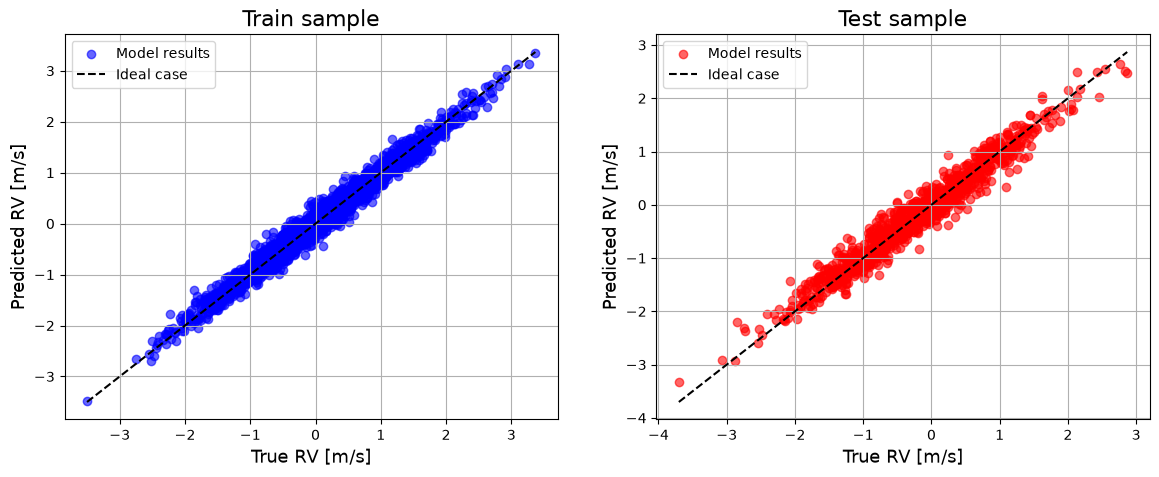

In [24]:
# plot true vs predicted for each sample
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

t.plot_true_vs_pred(y_train_true, y_train_pred, axs[0], 'blue')
t.plot_true_vs_pred(y_test_true_flat, y_test_nn_flat, axs[1], 'red')

axs[0].set_title('Train sample', size=16)
axs[1].set_title('Test sample', size=16)

print(Fore.BLUE + f'Standard deviation of the predicted train RVs: {y_train_pred.std():.3f}')
print(Fore.BLUE + f'Standard deviation of the train RVs: {y_train.std():.3f}\n')

print(Fore.RED + f'Standard deviation of the predicted test RVs: {y_test_nn_flat.std():.3f}')
print(Fore.RED + f'Standard deviation of the test RVs: {y_test.std():.3f}\n')

In [25]:
# arange data to superpose the plots above
data_train = {
    'y_train_true': y_train_true,
    'y_train_pred': y_train_pred,
}


data_test = {
    'y_test_true': y_test_true_flat,
    'y_test_pred': y_test_nn_flat
}

df_train = pd.DataFrame(data=data_train)
df_test = pd.DataFrame(data=data_test)

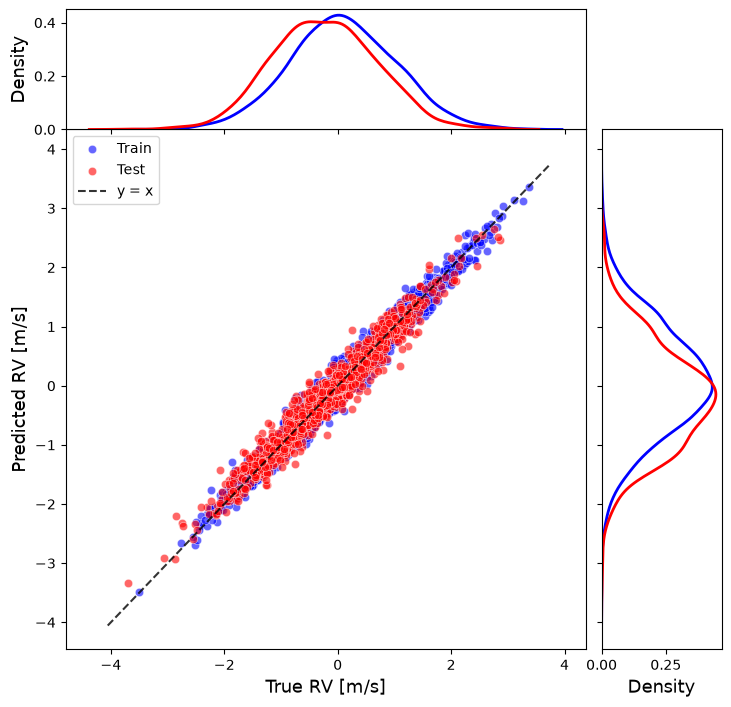

In [26]:
# Superposed with histograms

fig = plt.figure(figsize=(8, 8))

# Main scatter plot
ax = fig.add_axes([0.12, 0.12, 0.65, 0.65])

sns.scatterplot(
    data=df_train,
    x='y_train_true',
    y='y_train_pred',
    color='blue',
    alpha=.6,
    label='Train',
    ax=ax
)

sns.scatterplot(
    data=df_test,
    x='y_test_true',
    y='y_test_pred',
    color='red',
    alpha=.6,
    label='Test',
    ax=ax
)

# Reference line y = x
lims = ax.get_xlim()
ax.plot(lims, lims, '--', color='black', alpha=0.8, label='y = x')

ax.set_xlabel('True RV [m/s]', size=13)
ax.set_ylabel('Predicted RV [m/s]', size=13)
ax.legend()


# ---- Smooth marginal distributions ----

# Top: distributions of TRUE values
ax_top = fig.add_axes([0.12, 0.77, 0.65, 0.15], sharex=ax)

sns.kdeplot(
    data=df_train,
    x='y_train_true',
    color='blue',
    linewidth=2,
    ax=ax_top,
    label='Train'
)

sns.kdeplot(
    data=df_test,
    x='y_test_true',
    color='red',
    linewidth=2,
    ax=ax_top,
    label='Test'
)

ax_top.set_ylabel('Density', size=13)
ax_top.set_xlabel('')
ax_top.tick_params(axis='x', labelbottom=False)


# Right: distributions of PREDICTED values
ax_right = fig.add_axes([0.79, 0.12, 0.15, 0.65], sharey=ax)

sns.kdeplot(
    data=df_train,
    y='y_train_pred',
    color='blue',
    linewidth=2,
    ax=ax_right,
    label='Train'
)

sns.kdeplot(
    data=df_test,
    y='y_test_pred',
    color='red',
    linewidth=2,
    ax=ax_right,
    label='Test'
)

ax_right.set_xlabel('Density', size=13)
ax_right.set_ylabel('')
ax_right.tick_params(axis='y', labelleft=False)

plt.show()

In [27]:
# true - predicted for each sample
diff_train = y_train_true - y_train_pred
diff_test = y_test_true_flat - y_test_nn_flat

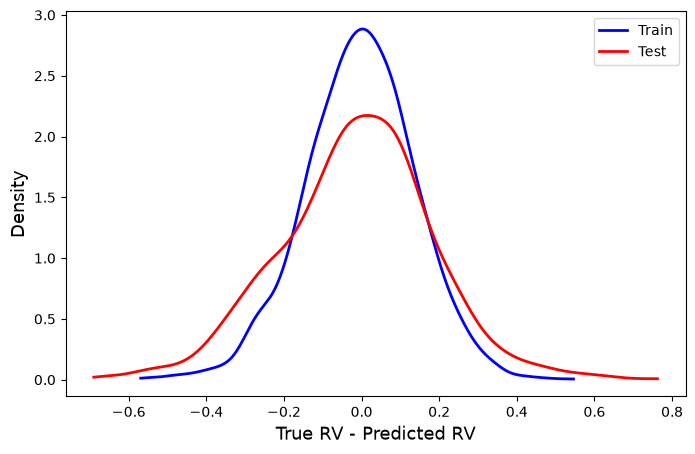

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

#ax.hist(diff_train, alpha=.5, density=True)
#ax.hist(diff_val, alpha=.5, density=True)
#ax.hist(diff_test, alpha=.5, density=True)

# Smooth KDE curve
# gaussian_kde: estimates the probability density function of a random variable
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html
kde_train = gaussian_kde(diff_train)
x_train = np.linspace(diff_train.min(), diff_train.max(), 500)

kde_test = gaussian_kde(diff_test)
x_test = np.linspace(diff_test.min(), diff_test.max(), 500)

# Density histograms
ax.plot(x_train, kde_train(x_train), linewidth=2, color='blue', label='Train')
ax.plot(x_test, kde_test(x_test), linewidth=2, color='red', label='Test')

ax.set_xlabel('True RV - Predicted RV', size=13)
ax.set_ylabel('Density', size=13)
ax.legend()

plt.show()

In [29]:
# compute means
mean_train = np.mean(diff_train)
mean_test = np.mean(diff_test)

# compute stds
std_train = np.std(diff_train)
std_test = np.std(diff_test)

In [30]:
print('---------- Mean of True-Predicted RV ----------')
print(f'Train: {mean_train:.5f}')
print(f'Test: {mean_test:.5f}')

print('---------- Std of True-Predicted RV ----------')
print(f'Train: {std_train:.4f}')
print(f'Test: {std_test:.4f}')

---------- Mean of True-Predicted RV ----------
Train: -0.00413
Test: -0.01327
---------- Std of True-Predicted RV ----------
Train: 0.1418
Test: 0.1968


In [31]:
# calculate std of True-Predicted (sigma) for each epoch

sigma_train = np.array(model_history['y_train_true']) - np.array(model_history['y_train_pred'])
#sigma_test = np.array(model_history['y_test_true']) - np.array(model_history['y_test_pred'])

sigma_train = np.std(sigma_train, axis=1)
#sigma_test = np.std(sigma_test, axis=1)

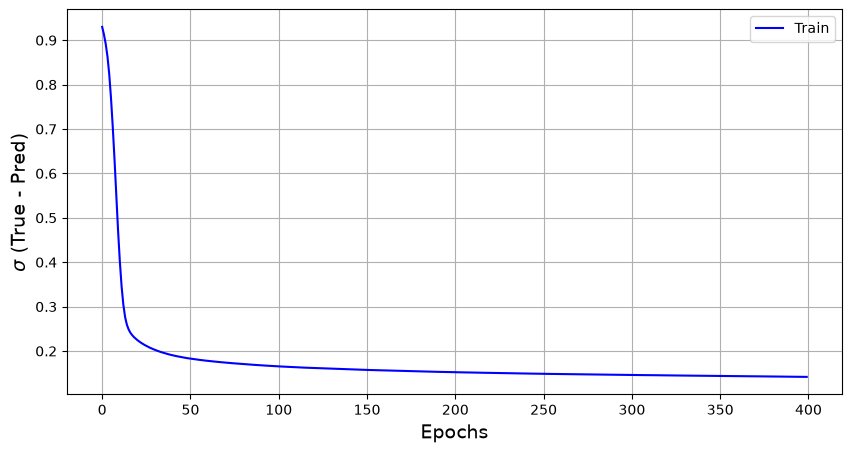

In [32]:
# plot sigma history

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()

ax.plot(sigma_train, color='blue', label='Train')
#ax.plot(sigma_test, color='red', label='Test')

ax.set_xlabel('Epochs', size=14)
ax.set_ylabel(r'$\sigma$ (True - Pred)', size=14)
ax.legend()
#ax.set_yscale('log')

plt.show()

In [33]:
# do a linear model (y = I * X) to compare with the result from the neural network
k = 20  # number of PCs used for the fit

scores_matrix = np.array(X)[:, :k]  # this is I in the fit, a matrix whose columns are the scores of the first k principal components

# separate the scores and RVs into sub samples
scores_train = np.array(X)[:train_size, :k]
scores_test  = np.array(X)[train_size:, :k]

rv = np.squeeze(np.array(y))  # RV data in a 1-d array
rv_train = rv[:train_size]
rv_test  = rv[train_size:]

# training the linear model

G = np.dot(scores_train.T, scores_train)
b = np.dot(scores_train.T, rv_train)
alpha = np.linalg.solve(G, b)

/tmp/ipykernel_996526/1088659544.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  scores_matrix = np.array(X)[:, :k]  # this is I in the fit, a matrix whose columns are the scores of the first k principal components
/tmp/ipykernel_996526/1088659544.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  scores_train = np.array(X)[:train_size, :k]
/tmp/ipykernel_996526/1088659544.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy

In [34]:
# use alpha to predict the RVs in chunks of 21 points from the test sample
y_test_linear = []
res_test_linear = []
i = 0
#chunk_size = 21  # already defined for the NN predictions

while i < len(rv_test):
    if i + chunk_size < len(rv_test):  # check that we are not depassing the number of data points while indexing
        scores_i = scores_test[i:i+chunk_size]
        rv_true = rv_test[i:i+chunk_size]
    else:
        scores_i = scores_test[i:]
        rv_true = rv_test[i:]

    pred = np.dot(alpha, scores_i.T)
    y_test_linear.append(pred)
    res_test_linear.append(rv_true - pred)
    i += chunk_size

print(f'{len(y_test_linear) - 1} chunks of {chunk_size} points and 1 chunk of {len(y_test_linear[-1])} points.')

52 chunks of 21 points and 1 chunk of 14 points.


In [35]:
mean_res_test_linear = np.array([np.mean(i) for i in res_test_linear])
std_res_test_linear = np.array([np.std(i) for i in res_test_linear])

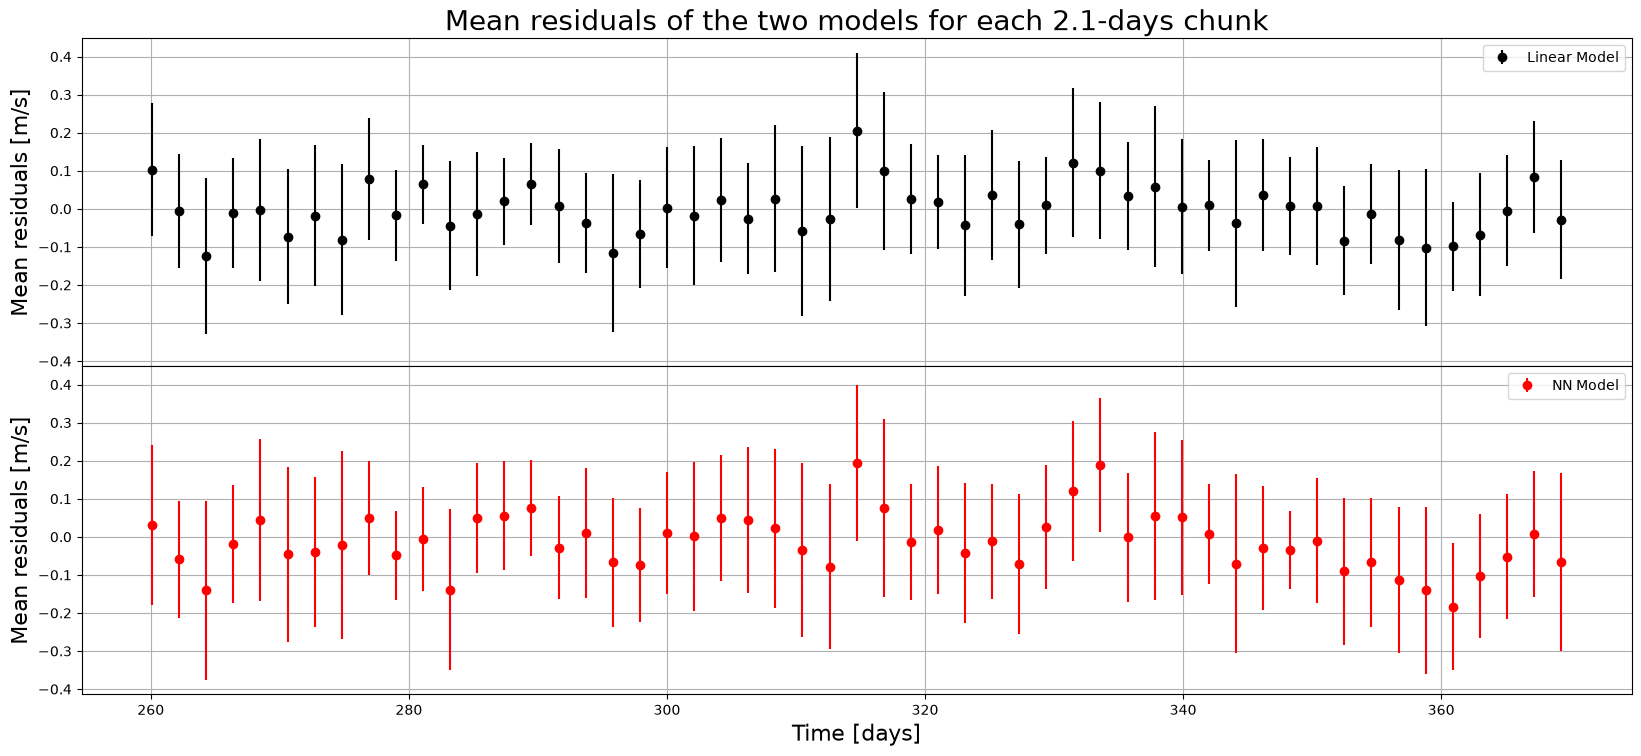

In [36]:
chunk_array = (np.linspace(1, len(y_test_linear), len(y_test_linear)) * chunk_size + train_size) * 144 / 60 / 24  # array of days corresponding to the test sample

fig, axs = plt.subplots(2, 1, figsize=(20, 8), sharex=True, sharey=True)
axs[0].set_title(f'Mean residuals of the two models for each {chunk_size / 10}-days chunk', size=20)

axs[0].grid()
axs[0].errorbar(chunk_array, mean_res_test_linear, std_res_test_linear, color='k', fmt='o', label='Linear Model')
axs[0].set_ylabel('Mean residuals [m/s]', size=16)
axs[0].legend()

axs[1].grid()
axs[1].errorbar(chunk_array, mean_res_test_nn, std_res_test_nn, color='red', fmt='o', label='NN Model')
axs[1].set_xlabel('Time [days]', size=16)
axs[1].set_ylabel('Mean residuals [m/s]', size=16)
axs[1].legend()

plt.subplots_adjust(hspace=0, top=.93)
plt.show()

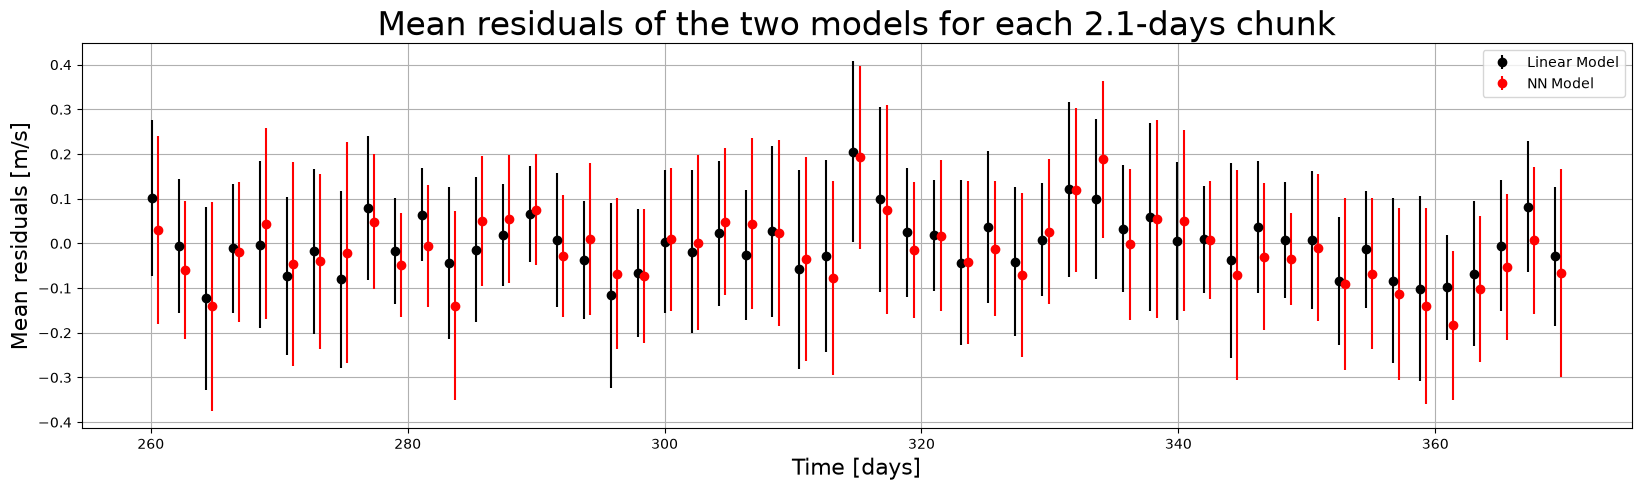

In [37]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.set_title(f'Mean residuals of the two models for each {chunk_size / 10}-days chunk', size=24)

ax.grid()
ax.errorbar(chunk_array, mean_res_test_linear, std_res_test_linear, color='k', fmt='o', label='Linear Model')
ax.errorbar(chunk_array+.5, mean_res_test_nn, std_res_test_nn, color='red', fmt='o', label='NN Model')

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('Mean residuals [m/s]', size=16)
ax.legend()

plt.show()

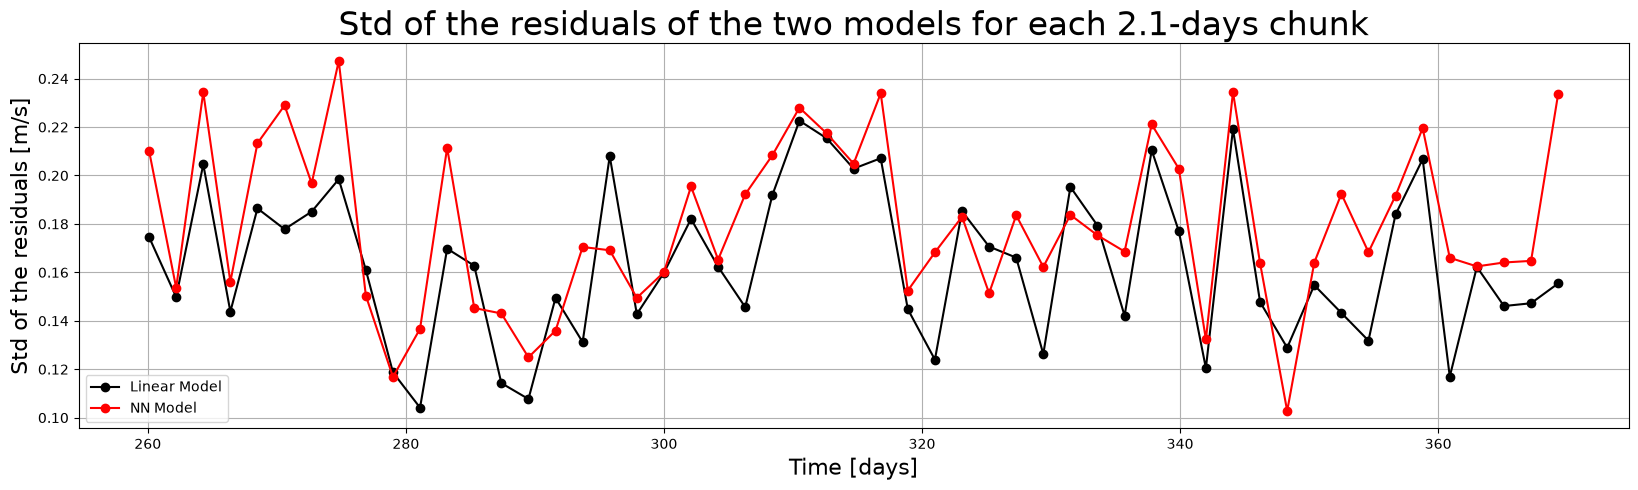

In [38]:
# comparing std of the residuals

fig, ax = plt.subplots(figsize=(20, 5))
ax.set_title(f'Std of the residuals of the two models for each {chunk_size / 10}-days chunk', size=24)

ax.grid()
ax.plot(chunk_array, std_res_test_linear, color='k', marker='o', label='Linear Model')
ax.plot(chunk_array, std_res_test_nn, color='red', marker='o', label='NN Model')

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('Std of the residuals [m/s]', size=16)
ax.legend()

plt.show()

In [39]:
std_count = sum(std_res_test_linear < std_res_test_nn)
chunks = len(std_res_test_linear)
print('The NN model has a standard deviation higher than the linear model in '
      f'{std_count} out of the {chunks} chunks.\n'
      f'That is {std_count / chunks * 100:.0f}% of the cases.')

The NN model has a standard deviation higher than the linear model in 43 out of the 53 chunks.
That is 81% of the cases.


In [54]:
y_test_linear_flat = np.concatenate(y_test_linear)
diff_test_linear   = rv_test - y_test_linear_flat

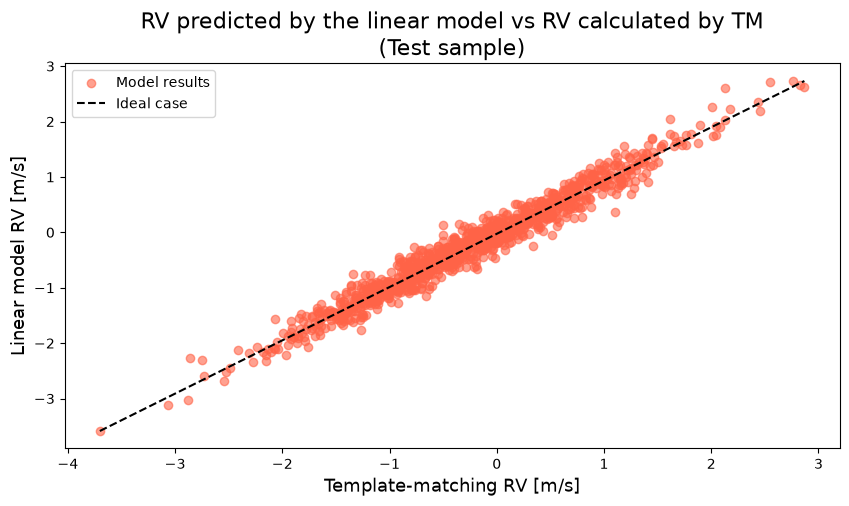

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('RV predicted by the linear model vs RV calculated by TM\n(Test sample)', size=16)

ax.scatter(rv_test, y_test_linear_flat, color='tomato', alpha=.6, label='Model results')
ax.plot([min(rv_test), max(rv_test)], [min(y_test_linear_flat), max(y_test_linear_flat)], linestyle='--', color='k', label='Ideal case')
ax.set_xlabel('Template-matching RV [m/s]', size=13)
ax.set_ylabel('Linear model RV [m/s]', size=13)
ax.legend()

plt.show()

In [56]:
times_test = times[train_size:]

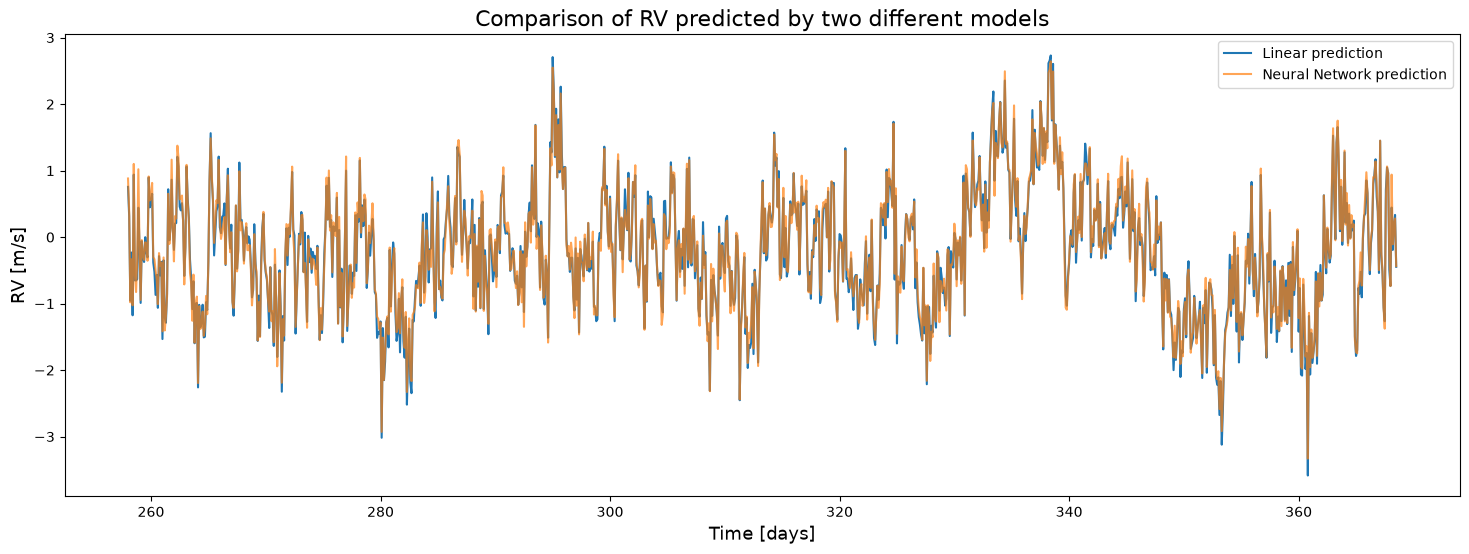

In [57]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.set_title('Comparison of RV predicted by two different models', size=16)

ax.plot(times_test, y_test_linear_flat, label='Linear prediction')
ax.plot(times_test, y_test_nn_flat, label='Neural Network prediction', alpha=.7)
#plt.plot(times_test, rv[train_size + val_size:])

ax.set_xlabel('Time [days]', size=13)
ax.set_ylabel('RV [m/s]', size=13)
ax.legend()

plt.show()

In [59]:
print('---------- Mean difference between True and predicted RVs ----------')
print(f'True RV - Linear prediction = {np.mean(diff_test_linear):.3f} m/s')
print(f'True RV - Neural Network prediction = {np.mean(diff_test_nn):.3f} m/s')
print(f'Linear prediction - Neural Network prediction = {np.mean(y_test_linear_flat - np.array(y_test_nn_flat)):.3f} m/s')

print('---------- Standard deviation of the difference between True and predicted RVs ----------')
print(f'True RV - Linear prediction = {np.std(diff_test_linear):.2f} m/s')
print(f'True RV - Neural Network prediction = {np.std(diff_test_nn):.2f} m/s')
print(f'Linear prediction - Neural Network prediction = {np.std(y_test_linear_flat - np.array(y_test_nn_flat)):.2f} m/s')

---------- Mean difference between True and predicted RVs ----------
True RV - Linear prediction = -0.002 m/s
True RV - Neural Network prediction = -0.013 m/s
Linear prediction - Neural Network prediction = -0.012 m/s
---------- Standard deviation of the difference between True and predicted RVs ----------
True RV - Linear prediction = 0.18 m/s
True RV - Neural Network prediction = 0.20 m/s
Linear prediction - Neural Network prediction = 0.11 m/s


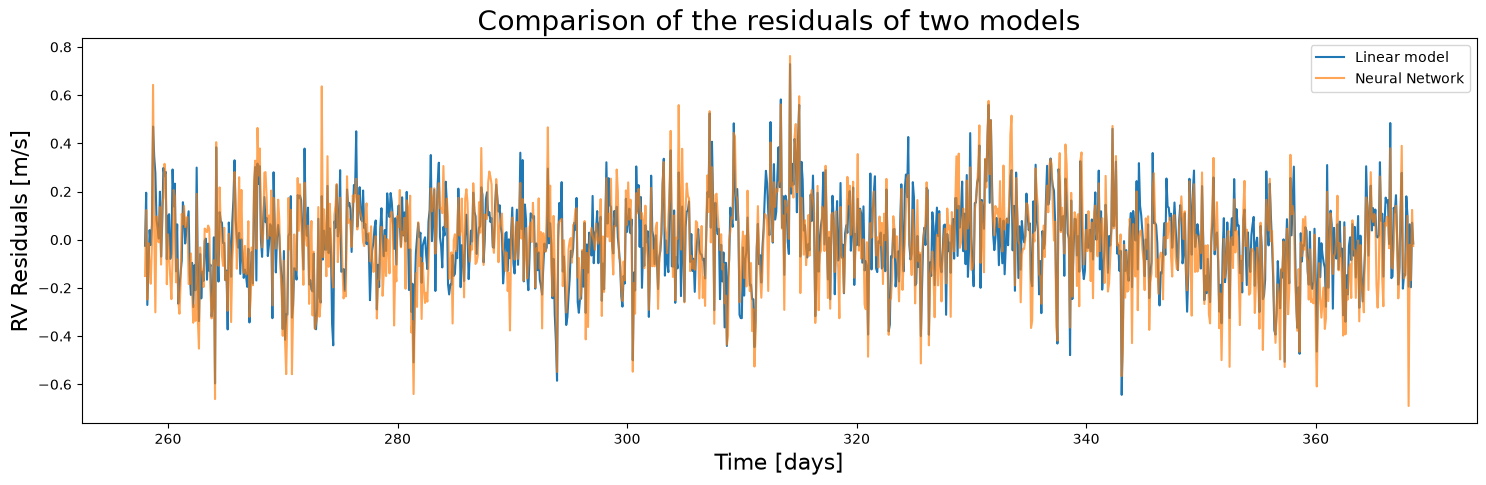

In [63]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.set_title('Comparison of the residuals of two models', size=20)

ax.plot(times_test, diff_test_linear, label='Linear model')
ax.plot(times_test, diff_test_nn, label='Neural Network', alpha=.7)

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('RV Residuals [m/s]', size=16)
ax.legend()

plt.show()

In [69]:
# calculate module of the residuals for the two models
print(f'Module of the residuals of the NN model:     {np.linalg.norm(diff_test_nn):.1f} m/s')
print(f'Module of the residuals of the linear model: {np.linalg.norm(diff_test_linear):.1f} m/s')

Module of the residuals of the NN model:     6.6 m/s
Module of the residuals of the linear model: 5.9 m/s


In [72]:
# calculate module of the residuals in each chunk (then avg and std) for the two models
mod_res_nn = np.array([np.linalg.norm(i) for i in y_test_nn])
avg_mod_nn = np.mean(mod_res_nn)
std_mod_nn = np.std(mod_res_nn)

mod_res_linear = np.array([np.linalg.norm(i) for i in y_test_linear])
avg_mod_linear = np.mean(mod_res_linear)
std_mod_linear = np.std(mod_res_linear)

print('Average +- std of the module of the residuals from the chunks:')
print(f'Module of the residuals of the NN model:     {avg_mod_nn:.2f} +- {std_mod_nn:.2f} m/s')
print(f'Module of the residuals of the linear model: {avg_mod_linear:.2f} +- {std_mod_linear:.2f} m/s')

Average +- std of the module of the residuals from the chunks:
Module of the residuals of the NN model:     3.96 +- 1.33 m/s
Module of the residuals of the linear model: 3.98 +- 1.43 m/s


In [61]:
# are PCs correlated with the residuals?
diff_all = np.concatenate((diff_train, diff_test))
corr_all = []

for i in range(M):
    scores_i = scores_matrix[:, i]
    corr = ss.pearsonr(diff_all, scores_i)[0]
    corr_all.append(corr)

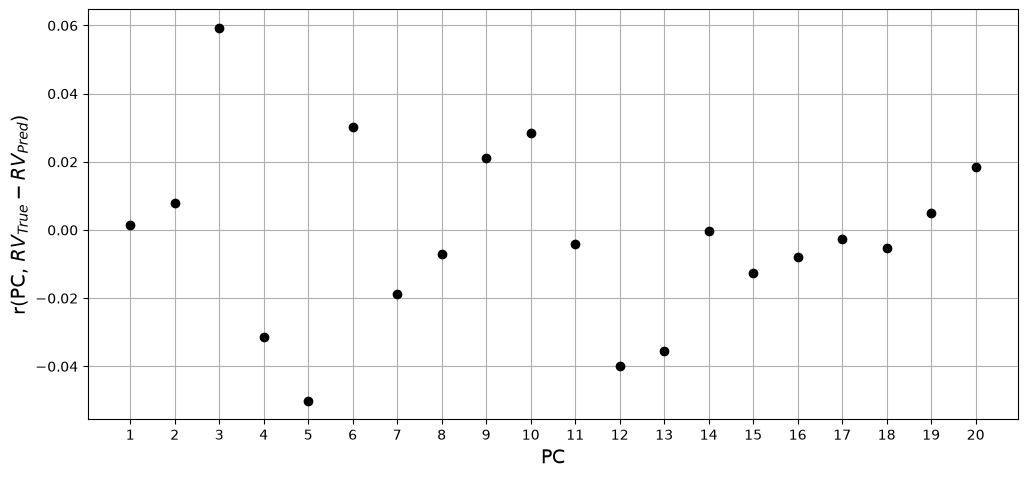

In [62]:
pc_arr = np.linspace(1, M, M)

fig, ax = plt.subplots(figsize=(12, 5))
ax.grid()

ax.scatter(pc_arr, corr_all, color='k', zorder=2)
ax.set_xlabel('PC', size=14)
ax.set_xticks(pc_arr)
ax.set_ylabel(r'r(PC, $RV_{True} - RV_{Pred}$)', size=14)

plt.subplots_adjust(top=.93)
plt.show()